# EE 120 实验 2：LTI 滤波的应用

v1 - 2019 春：Dominic Carrano、Sukrit Arora 和 Babak Ayazifar  
v2 - 2019 秋：Dominic Carrano

# 背景

现在你已经熟悉了 iPython Notebook 环境以及 Python 的科学计算能力，接下来就可以用这些技能来探索 LTI 滤波的一些应用。

本实验中会看到一些你可能在课堂上已经见过的滤波器，例如移动平均滤波器和边缘检测器。不同之处在于，我们可以让计算机完成卷积计算和绘图等工作，因此能够观察这些滤波器在更大、更有意思的信号上的表现。具体来说，我们会研究这两类滤波器，以及它们作用于不同类型信号时的多种解释和应用。之后，我们还会深入学习 MACD 指标，了解它如何用于股票市场金融数据分析。

## 连续图（用 `plt.plot` 插值绘制）与离散图（用 `plt.stem` 绘制）

虽然本实验中我们仍然把信号看作离散时间信号，但很多信号会比较长，可能包含几百甚至几千个采样值。因此，除非特别说明，**本实验中所有信号都应使用 `plt.plot` 绘图**。

在实验 1 中我们几乎一直使用 `plt.stem`，但茎状图有两个主要缺点，而连续样式的曲线图（也就是用 `plt.plot` 绘制、会对信号进行插值显示的图）没有这些问题：
- 很难在同一张茎状图上叠加多个信号并进行直观比较。
- 茎状图的渲染时间会随着信号长度显著变差。
    - 为了感受这种差距，我们曾在一台 2015 款 MacBook Pro 上比较 `plt.stem` 和 `plt.plot` 的绘图时间。平均来看，长度为 1000 的矩形信号用 `plt.plot` 约需 100 ms，而用 `plt.stem` 需要 2 到 3 秒；长度为 10000 的矩形信号用 `plt.plot` 约需 200 ms，而用 `plt.stem` 需要 1.5 到 2 **分钟**。
    - 还记得实验 1 的 Q3c 中，我们反复对矩形信号做卷积，并观察到最终会得到高斯形状（钟形曲线）吗？你可能注意到后续结果显示得越来越慢。问题并不是卷积本身因为信号长度增加而花费很久（卷积运行时间确实随长度增加，但影响很小），真正的瓶颈是反复绘制茎状图。

以上两个原因也是现实应用中几乎所有图都使用插值曲线图的原因。需要注意的是，在数字信号处理时，连续世界和离散世界之间其实有更复杂的关系：
1. 连续时间信号 $x(t)$ 以某个采样间隔 $T$ 进行采样，在 $T$ 的整数倍处得到 $N$ 个采样值 $x(nT)$。然后定义 $x[n] = x(nT)$，得到可以在计算机上处理的离散时间信号；注意 $n = 0,1,..., N-1$，因为我们只有 $N$ 个采样点。多数实际信号持续时间有限，因此可以选择足够大的 $N$ 来覆盖整个信号。
2. 在计算机上对 $x[n]$ 进行处理，得到相关信号 $y[n]$。
3. 通过插值把 $y[n]$ 绘制成连续时间样式的图。

这和实验 1 中关于时间索引中“零点”含义的约定类似，都是信号与系统在实际应用中的细节，需要通过实践逐渐熟悉。

在本实验中，有些信号只是为了测试不同滤波器而人为构造的“测试信号”，此时上面的 1 到 3 步并不重要；但在其他部分，我们会使用真实世界的数据，因此最好把这三步的含义理清楚。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Q1：一维边缘检测器

一维边缘检测器用于信号处理中，顾名思义，是为了检测信号幅度中的边缘或跳变。之所以称为一维，是为了区别于图像处理中使用的二维边缘检测滤波器。只包含“幅度随时间变化”信息的基本信号通常称为“一维”信号，而图像常被看作“二维”信号；视频则可看作“三维”信号，其中时间（逐帧变化）是第三个维度。在 EE 120 中，你遇到的大多数信号都会是一维信号。

一维边缘检测器的冲激响应定义为：

$$h[n] = \delta[n] - \delta[n - 1]$$

在本题中，我们会探索边缘检测器的几个重要性质。

这个滤波器的工作方式是：对每一对相邻的信号值求差。如果输入是一串常数值，那么滤波器会反复输出 0，因为没有“边缘”。

类似地，如果信号在时间 $n-1$ 处为 0，在时间 $n$ 处为 1，那么滤波器会在时间 $n$ 输出 1，表示检测到一个“大小”为 1 的边缘。这个滤波器还会编码边缘的“方向”信息：如果反过来，时间 $n-1$ 处为 1，时间 $n$ 处为 0，那么输出（在时间 $n$）就是 -1。

因此，一维边缘检测器可以看作离散时间中“求导”的等价操作，这个思想会在本题 b 部分进一步讨论。

## Q1a：分段常数信号

我们会用这个滤波器做两个例子。首先把它用于分段常数信号。若一个离散时间信号只由若干段常值片段组成，并且每段持续超过一个采样点，我们就称它为“分段常数”信号。下面前两个信号是分段常数信号，第三个不是。

<img src="q1pic.png" width="1200px" />

### 你的任务

在下面的单元格中：  
- 使用时间索引 $\{0, 1, ..., 19, 20\}$，定义分段常数信号 $x$：

$$x[n] = \sum_{k = 5}^{9} \delta[n - k] + 3\sum_{k = 10}^{13} \delta[n - k] + 2\sum_{k = 14}^{18} \delta[n - k]$$

- 定义边缘检测器的冲激响应 $h$，但只定义其非零点（也就是说，表示 $h$ 的 numpy 数组只包含两个元素）。
    - 在本实验中，我们通常只在冲激响应的非零点上定义它们，以避免偏移问题，并在卷积时使用 `"same"`。正如你在实验 1 中看到的，`"same"` 会把卷积结果截断为与两个输入中较长者相同的长度，并从结果边缘裁掉部分点。本质上，`"same"` 与 `"full"` 类似，只是多了一步截断；必要时我们会对输入信号补零来处理这个问题。
- 使用 `"same"` 作为卷积模式，计算 $y = x * h$。
- 完成以上三步后，运行该单元格来绘制结果（绘图代码已经提供）。

In [8]:
# TODO your code here
n=np.arange(0,21)
x=np.zeros(21)
x[5:10]+=1
x[10:14]+=3
x[14:19]+=2
h=np.array([1,-1])
y=np.convolve(x,h,mode='same')

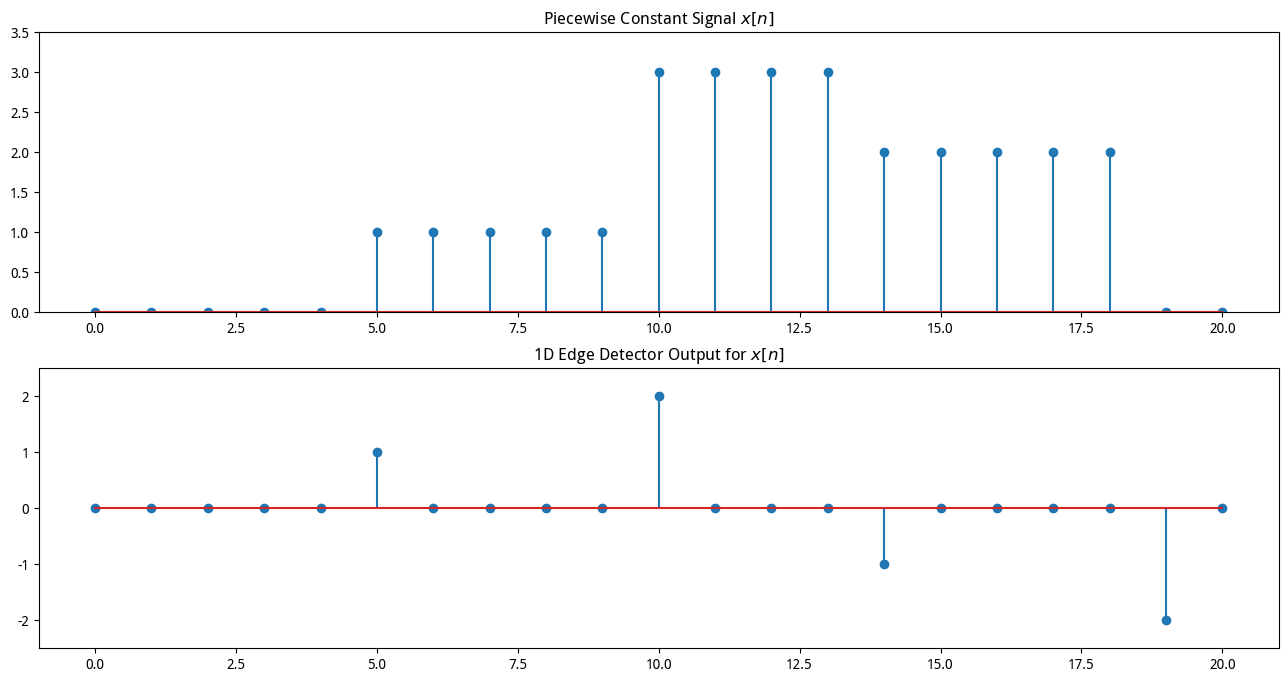

In [9]:
# Plot results
plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
plt.stem(n, x)
plt.ylim([0, 3.5])
plt.title("Piecewise Constant Signal $x[n]$")

plt.subplot(2, 1, 2)
plt.stem(n, y)
plt.ylim([-2.5, 2.5])
plt.title("1D Edge Detector Output for $x[n]$")

plt.show()

**问题：** $x$ 是一个分段常数信号，总共变化四次：先从 0 变到 1，再从 1 变到 3，再从 3 变到 2，最后从 2 变到 0。边缘检测器输出中有多少个非零点（也就是检测到了多少个边缘）？

<span style="color:blue">**答案：** 四个。</span>

**问题：** 过去约 15 年中，信号处理最热门的领域之一是对稀疏信号（大部分为零的信号）的研究，包括采集与表示，这通常被称为*压缩感知*。压缩感知算法中的一个关键步骤，是对信号施加某种*稀疏化变换*：该变换保留信号的全部信息（也就是说，原始信号可以从变换后的信号中完全恢复），但得到的新信号大部分为零。

假设你想为分段常数信号设计压缩感知算法，需要一种方法把它们稀疏化。你会如何只使用第一个信号值 $x(0)$，并选择一个 LTI 滤波器作为稀疏化变换来实现这一点？请说明你会使用什么 LTI 滤波器，以及如何从滤波后的信号恢复原信号。你可以忽略真实信号中的噪声，假设信号确实像上面的例子一样是分段常数的。同时，你可以假设 $x(n) = 0$ 对所有 $n < 0$ 成立，因为这基本上就是我们在数字实现中的处理方式。

<span style="color:blue">**答案：** 使用一阶差分滤波器 $h[n]=\delta[n]-\delta[n-1]$，因此变换后的信号为 $y[n]=x[n]-x[n-1]$。对于分段常数信号，相邻采样点通常相等，所以 $y[n]$ 中大多数值为 0，只有跳变点非零。因此，$y[n]$ 是原信号的一种稀疏表示。由于 $y[n]$ 记录了相邻采样点之间的变化量，原信号可以由初始值 $x[0]$ 通过累加恢复：$x[n] = x[0] + \sum_{k=1}^{n} y[k]$。所以只保存 $x[0]$ 和稀疏差分信号就足以重构 $x[n]$。</span>

## Q1b：把边缘检测器看作离散时间微分器

一维边缘检测器有时也称为*移动差分*滤波器，因为它通过相邻点相减来工作。这与微积分中函数求导的思想有很自然的联系；把它看成离散时间版本的求导，可以发现一维边缘检测器的许多性质。

回忆一下，对于函数 $f: \mathbb{R} \xrightarrow{} \mathbb{R}$，它的导数定义为

$$f'(t) = \lim_{\Delta t \xrightarrow{} 0}\dfrac{f(t + \Delta t) - f(t)}{\Delta t}$$

当 $\Delta t$ 越来越小时，我们得到的 $f'(t)$ 近似也越来越好。但在离散时间中，信号的自变量必须是整数，所以 $\Delta t$ 也必须是整数。它能取到的最小非零值是 1，此时就得到了与一维边缘检测器相同的公式。

下面我们重新回顾一些你在微积分课上见过的经典结果，只不过这次不用实数自变量函数，而使用离散时间信号。

### 你的任务

在下面的单元格中：
- 创建一个长度为 50 的*斜坡信号* $r$，定义为
$$r[n] = \sum_{k=1}^{50} k \delta[n - k] = \delta[n - 1] + 2 \delta[n - 2] + 3 \delta[n - 3] + ... + 50 \delta[n - 50]$$
- 计算 $y = r * h$，其中 $h$ 是与 Q1a 中相同的（未补零的）一维边缘检测器冲激响应。**卷积模式使用 `"valid"`**，因为我们只想在实际信号值完整重叠的位置做差分。
- 在上下两个独立图中（或者像 Q1a 提供的代码那样在同一 figure 中使用两个子图也可以），绘制 $r$ 和 $y$，上面画 $r$，下面画 $y$。关于绘图有几条要求：
    - **使用 `plt.stem` 绘制茎状图**。
    - 给图添加合理的标题。

<StemContainer object of 3 artists>

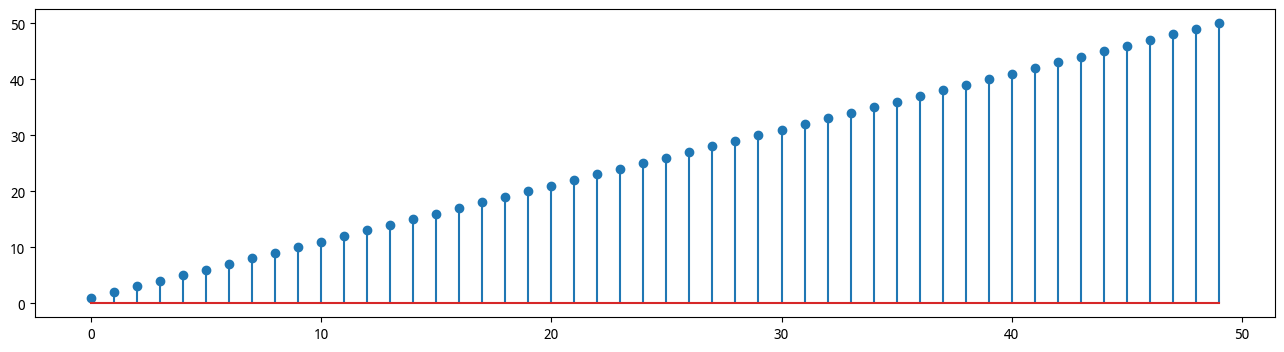

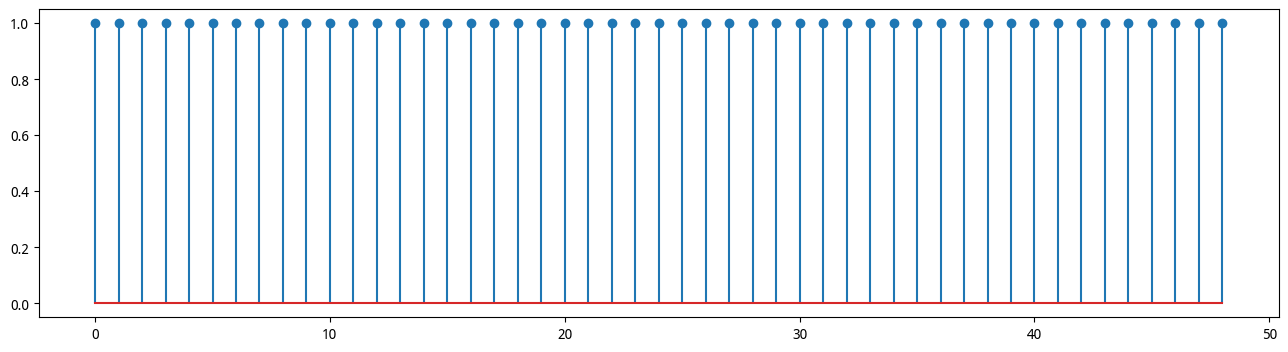

In [10]:
# TODO your code here
r = np.array([i for i in range(1, 51)])
h = np.array([1, -1])
y = np.convolve(r, h, mode="valid")
plt.figure(figsize=(16,4))
plt.stem(r)
plt.figure(figsize=(16,4))
plt.stem(y)

**问题：** 斜坡信号线性增加。你应该能在图中看到，一维边缘检测器，也就是移动差分，对斜坡信号的输出是一个常数信号。这个斜坡信号让你想到哪个实函数（$f(t) = ?$）？这个函数的导数是什么（$f'(t)$ 是什么）？这个导数与边缘检测器输出之间有什么对应关系？

<span style="color:blue">**答案：** $f(t) = t, f'(t) = 1$。</span>

再做一个例子！在下面的单元格中：
- 创建一个长度为 51 的二次信号 $x[n] = n^2$，其中 $n = 0, 1, ..., 50$。
- 像上一个例子一样计算 $y = x * h$，其中 $h$ 是（未补零的）一维边缘检测器冲激响应。同样使用 `"valid"` 模式。
- 以与上一个例子中绘制 $r$ 和 $y$ 相同的方式绘制 $x$ 和 $y$，并让 $x$ 的图在 $y$ 的图上方。

<StemContainer object of 3 artists>

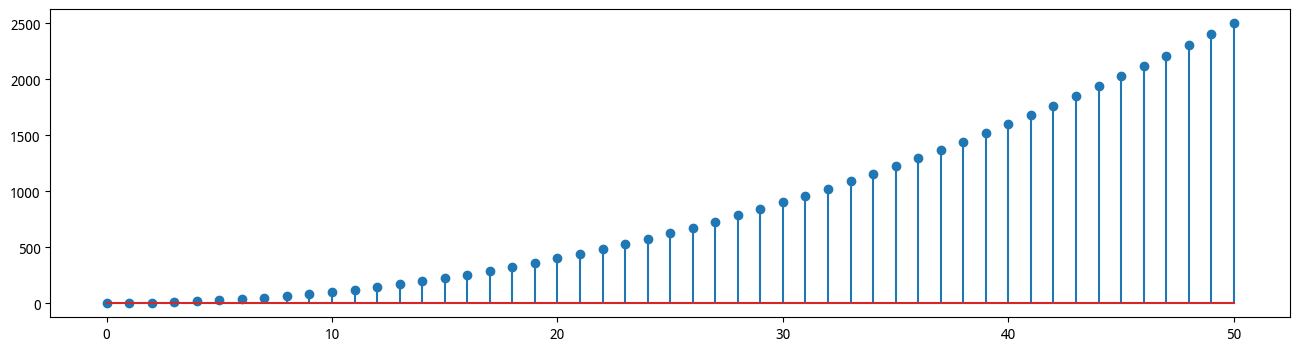

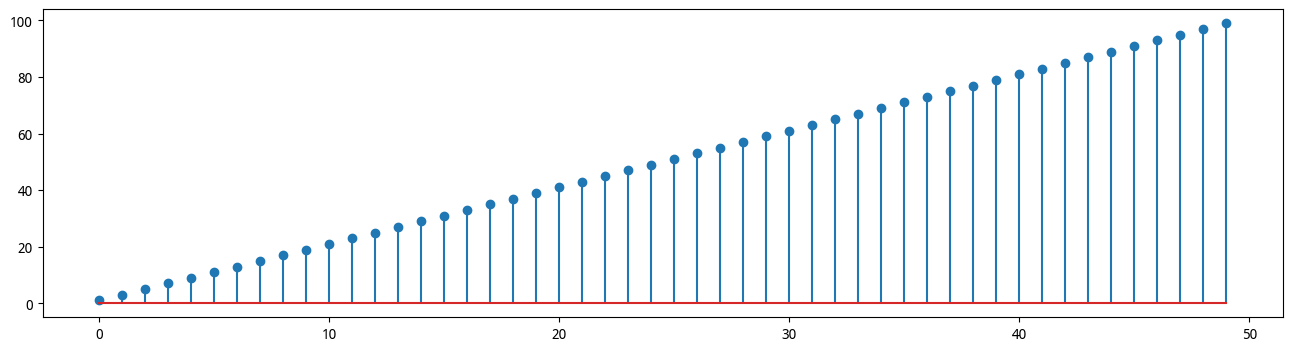

In [11]:
# TODO your code here
x = np.array([i**2 for i in range(51)])
y = np.convolve(x, h, mode="valid")
plt.figure(figsize=(16, 4))
plt.stem(x)
plt.figure(figsize=(16, 4))
plt.stem(y)

**问题：** 与前面相同。你应该能在图中看到，一维边缘检测器，也就是移动差分，以二次信号作为输入时会输出一个斜坡信号。这个二次信号让你想到哪个实函数（$f(t) = ?$）？这个函数的导数是什么（$f'(t)$ 是什么）？这个导数与边缘检测器输出之间有什么对应关系？

<span style="color:blue">**答案：** $f(t) = t^2, f'(t) = 2t$。</span>

## Q1c：“微分”噪声

现在我们已经在分段常数信号上尝试了边缘检测器，接下来把它用于一个不那么规整的信号：噪声。在本部分以及移动平均滤波部分中，我们会使用通常称为“高斯噪声”的信号作为测试信号。

### 什么是“噪声”？

在许多真实应用中，当你使用采集到的数据（也就是信号）时，通常无法直接得到原始信号（记为 $x$）。相反，你得到的是 $\tilde{x} = x + z$，其中 $z$ 是污染信号的“噪声”。信号处理、机器学习、统计学、数据科学以及许多其他应用领域的一个重要目标，就是尽可能从测得的信号 $\tilde{x}$ 中提取有意义的信息。对 $z$ 进行建模时，一个常见选择是“高斯噪声”。这个名称来自于噪声本身是随机的，因此必须从某个概率分布中抽取，而这里使用的就是高斯分布。选择高斯模型的理由与[中心极限定理](https://en.wikipedia.org/wiki/Central_limit_theorem)有关，因为在许多情况下，叠加在信号上的噪声是大量不同随机因素共同作用的结果。例如，电子电路中的[热噪声](https://en.wikipedia.org/wiki/Johnson%E2%80%93Nyquist_noise)来自粒子之间的相互碰撞，这种噪声被发现非常接近高斯分布；这也很合理，因为参与的原子数量非常大，每一对相互作用的原子都可以看作一个独立的随机事件。

正如实验 1 中提到的，本课程不要求你掌握概率论。但由于高斯噪声模型在信号处理中非常常用，所以很值得把它作为测试信号来做实验。

### 你的任务

下面已经为你定义好了信号 `noise`：

In [12]:
noise = np.random.normal(0, 5, 1000) # 1000 samples of mean=0, stddev=5 gaussian noise
noise.shape

(1000,)

现在，添加代码将（未补零，即 numpy 数组长度为 2 的）边缘检测器应用到它，并把结果存储在 `noise_filt` 中。同样使用 `"valid"` 作为卷积模式。绘图代码已经提供，你在这一部分不需要写太多代码。

注意，从这里开始我们会使用 `plt.plot`。因为我们会使用更长的信号（这里生成了 1000 个噪声样本），除了 `plt.plot` 更高效之外，它也更容易让我们观察结果，这一点在“背景”部分已经提到过。

In [13]:
# TODO your filtering code here; store result in noise_filt
noise_filt =  np.convolve(noise, h, mode="valid")

注意：信号 `noise_filt` 和 `noise` 不一定都落在我们为图像设置的 -20 到 20 的 y 轴范围内。由于它们是随机的，所以无论滤波前还是滤波后，都可能抽到超出该范围的数值。

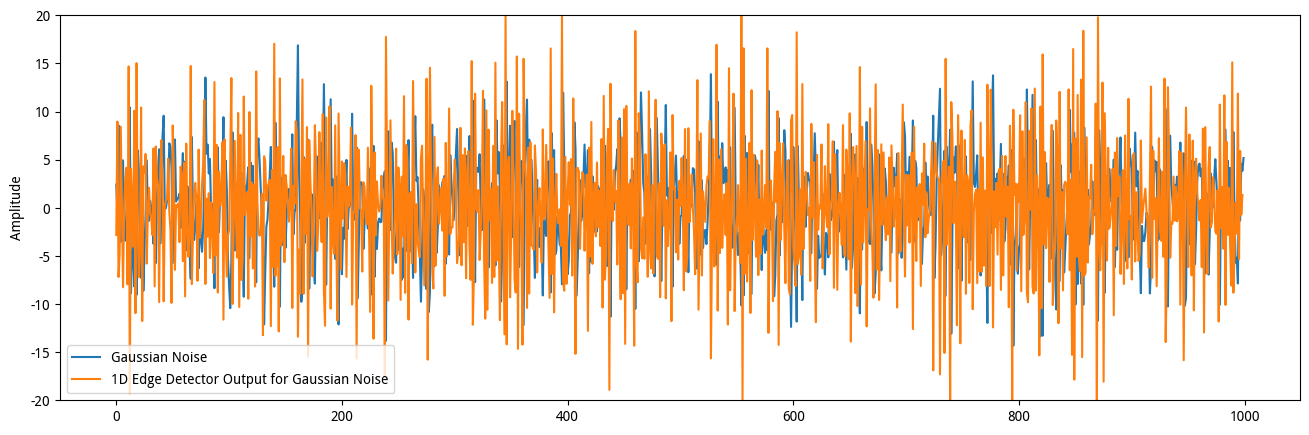

In [14]:
# Plot results
plt.figure(figsize=(16, 5))
plt.plot(noise)
plt.plot(noise_filt)
plt.ylim([-20, 20])
plt.ylabel("Amplitude")
plt.legend(("Gaussian Noise", "1D Edge Detector Output for Gaussian Noise"))
plt.show()

**问题：** 从定性角度看，这个滤波器是放大还是抑制了噪声的“强度”？如果我们想在被大量噪声污染的信号上检测边缘，这会带来什么启示？

<span style="color:blue">**答案：** 从定性上看，这个滤波器会放大噪声强度。由于该滤波器计算一阶差分 $y[n]=x[n]-x[n-1]$，它对相邻采样点之间的快速变化非常敏感。噪声通常含有许多高频波动，因此差分操作会让噪声更加明显。这说明，如果要在强噪声信号中检测边缘，不应直接单独使用边缘检测器；通常需要先对信号进行平滑或降噪，或者使用更鲁棒的边缘检测方法。</span>

# Q2：数据平滑

LTI 滤波器最常见的用途之一是数据平滑。它的应用很多，包括降噪、从复杂数据中提取趋势、插值等。在本题中，我们会探索其中最简单、但也可能是最广泛使用的数据平滑方法：移动平均滤波器。

## Q2a：降噪

*简单*移动平均滤波器由一个整数参数 $L$ 指定，$L$ 表示滤波器长度。该滤波器会对信号当前点以及之前的 $L-1$ 个点取平均，并输出这个平均值。形式上，它的冲激响应为：

$$h_{SMA}[n] = \frac{\delta[n] + \delta[n - 1]\ +\ ...\ +\ \delta[n - (L - 1)]}{L}$$

注意，这里使用的是*因果*移动平均滤波器：任意时刻的输出只由当前以及之前的信号值平均得到。你可能已经认出了这个冲激响应——它就是长度为 $L$ 的矩形信号，并且被归一化到总和为 1。

冲激响应下标中的 “SMA” 代表 *Simple Moving Average*，也就是简单移动平均，表示所有点在计算平均时权重相同。这区别于更复杂的移动平均，例如*指数移动平均*（EMA），它会给最近的数据点更高权重。后面你会有机会探索 EMA。如果感兴趣，也建议阅读参考文献 [1]，了解更多移动平均滤波器用于降噪的理论。

### 你的任务：信号生成

在下面的单元格中完成以下操作：
- 生成时间索引 $\{0, 1, ..., 999, 1000\}$。
- 在这些时间索引上生成信号 $x[n] = e^{n / 300}$。
- 在 $x$ 末尾追加 500 个 0，并扩展时间索引以包含这些额外数据点。也就是说，新的时间索引应为 $\{0, 1, ..., 1000, 1001, ..., 1500\}$。
- 使用 [np.random.normal](https://docs.scipy.org/doc/numpy/reference/generated/numpy.random.normal.html) 并设置参数 `loc=0, scale=4, size=np.shape(x)`，生成与 $x$ 形状相同的噪声 $z$。
    - 回忆实验 1 Q1，`np.shape(x)` 会返回 `x` 在每个维度上的元素个数（这里信号是一维的，所以 `np.shape` 只返回元素个数），我们可以把它传给 numpy 函数，从而方便地生成与某个 numpy 数组大小相同的数组（也就是信号）。
- 创建带噪声信号 $y = x + z$。
- 在同一个 16x4 的图中绘制 $x$ 和 $y$。使用 [plt.legend](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.legend.html)，把 $x$ 标注为 “True Signal”，把 $y$ 标注为 “Noised Signal”。**确保绘图时使用 `plt.plot`，不要使用 `plt.stem`。** 你应该把生成的时间索引作为 `plt.plot` 的第一个参数。

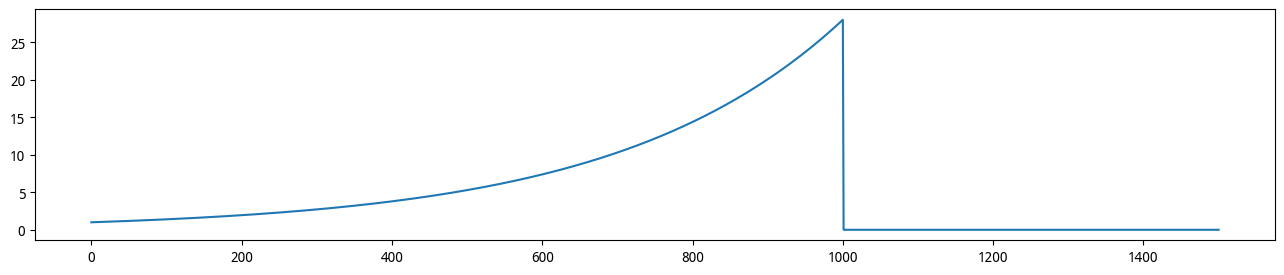

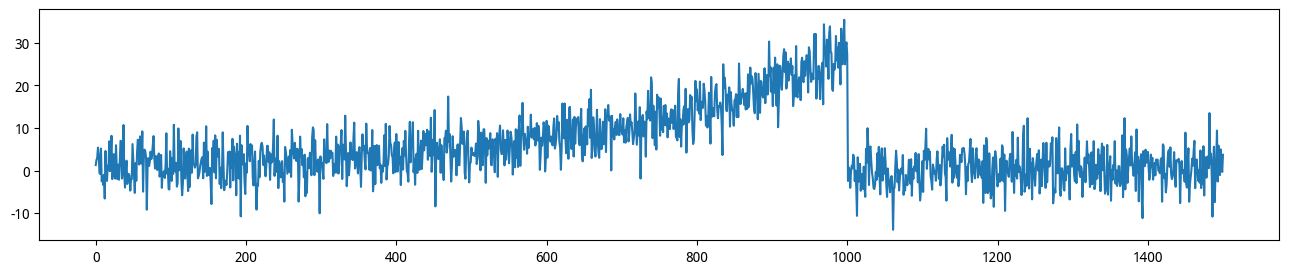

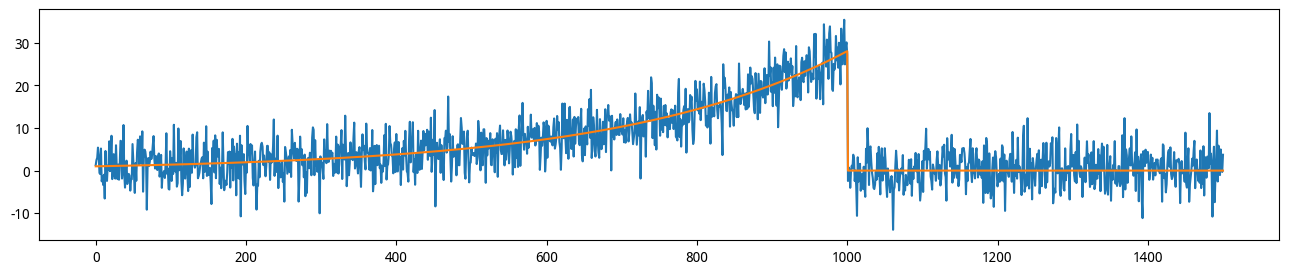

In [21]:
# TODO your code here
t = np.arange(0,1001)
x = np.exp(t/300)
x = np.concatenate((x,np.zeros(500)))
t = np.arange(0,1501)
z = np.random.normal(loc=0,scale=4,size=np.shape(x))
y = x + z
plt.figure(figsize=(16,3))
plt.plot(t, x, label="True Signal")
plt.figure(figsize=(16,3))
plt.plot(t, y, label="Noised Signal")
plt.figure(figsize=(16,3))
plt.plot(t, y, label="Noised Signal")
plt.plot(t, x, label="True Signal")

如果代码正确，你应该看到一个指数信号：前 1000 个采样点内幅度从 0 附近上升到约 30，之后接着 500 个 0。叠加在它上面的带噪信号会上下跳动，**但从平均趋势来看，会跟随原始信号的幅度变化**。

### 你的任务：信号降噪

现在我们已经得到了一个“不太好看”的带噪信号，接下来尝试用移动平均来降噪。直观地说，由于带噪信号在平均意义上跟随原始信号，因此通过对相邻数据点求平均，应该可以在一定程度上减小噪声。难点在于如何选择每次平均的点数，这也是一个非常典型的工程权衡问题。

数组 `filt_sizes` 已经为你定义好，其中包含我们要尝试的不同滤波器长度（也就是上面的参数 $L$）。在下面的单元格中：
- 创建一个 20x35 的图。我们会创建一列子图，每个滤波器长度对应一个子图（注意 `len(filt_sizes)` 为 7）。
- 对 `filt_sizes` 中的每个滤波器长度：
    - 创建一个对应长度的简单移动平均滤波器 $h$。
        - 不需要对 $h$ 做任何补零；只需在它非零的位置上构造滤波器。
    - 计算 $\hat{x} = y * h$，其中 $y$ 是你上面创建的带噪指数增长信号。代码中可以把这个变量命名为 `x_hat`。**卷积模式使用 `"full"`。** 如果不用 `"full"`，由于我们定义冲激响应的方式，滤波器会变成非因果的。
    - 在一个新的子图中（也就是说，每一种不同的移动平均滤波器使用一个单独子图）：
        - 绘制原始无噪信号 $x$。你可以使用上面定义的变量 $n$ 作为时间索引。
        - 绘制当前循环中计算得到的移动平均版本 $\hat{x}$。
            - 由于我们没有使用 `"same"` 进行卷积（这是为了得到因果滤波器），因此需要扩展后的时间索引用于绘图。
            - 作为提示，代码可以写成 `n_aug = np.concatenate((n, np.arange(n[-1], n[-1] + (len(x_hat) - len(n)))))`。它会根据卷积把信号 $x$ 拉长了多少，在已有时间索引末尾追加额外索引。
        - 使用 `plt.legend`，把 $x$ 标注为 “True Signal”，把 $\hat{x}$ 标注为 “Noised Signal after ?-point SMA”，其中 “?” 应替换为当前滤波器长度。Python 的 [format](https://www.digitalocean.com/community/tutorials/how-to-use-string-formatters-in-python-3) 函数可能会有帮助。

**注意：** 每个滤波器长度下，$\hat{x}$ 和 $h$ 都会变化；而 $x$ 和 $y$ 不变。

**提示 1：** 把子图按一列显示最有信息量。因此，你调用 `plt.subplot` 时应类似于 `plt.subplot(len(filt_sizes), 1, i)`，其中 `i` 是记录当前子图编号的变量（从 1 开始，每创建并应用一种不同的移动平均滤波器就增加 1）。

**提示 2：** 确保在创建完所有子图之后再调用 `plt.show()`（也就是说，不要在循环内部调用）。每个 figure 只需要调用一次 `plt.show()`，即在完成所有子图生成之后调用。

In [23]:
filt_sizes = [2, 5, 10, 20, 50, 100, 500]

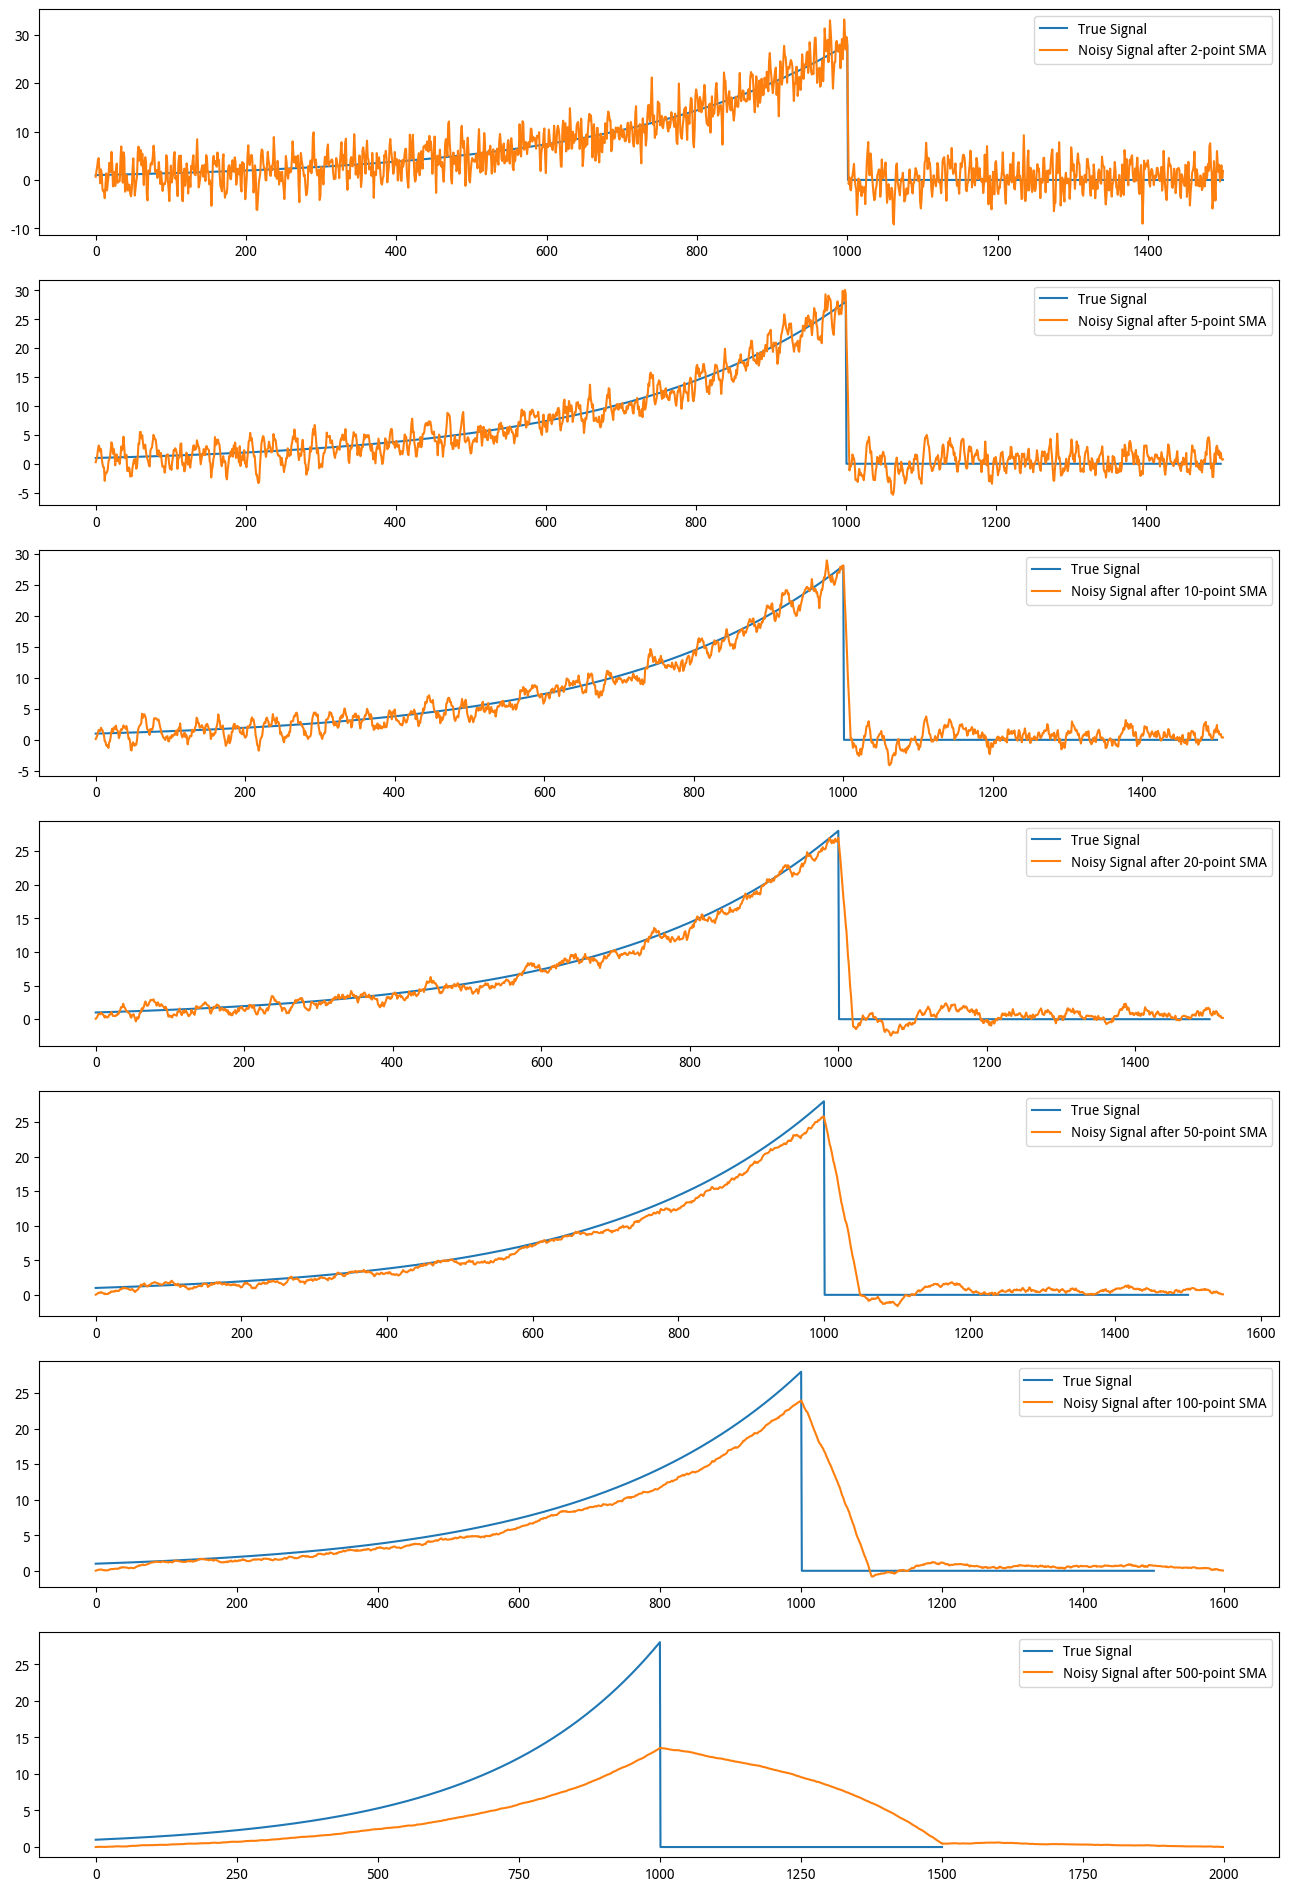

In [24]:
# TODO your code here
plt.figure(figsize=(16, 24))

for i, filt_size in enumerate(filt_sizes):
    h = np.ones(filt_size) / filt_size
    x_hat = np.convolve(y, h, mode="full")

    t_aug = np.concatenate(
        (t, np.arange(t[-1], t[-1] + (len(x_hat) - len(t))))
    )


    plt.subplot(len(filt_sizes), 1, i + 1)
    plt.plot(t, x, label="True Signal")
    plt.plot(t_aug, x_hat, label=f"Noisy Signal after {filt_size}-point SMA")
    plt.legend()

plt.show()


一些合理性检查：
- 在所有情况下，真实信号都应该从 0 到 1500，并且看起来相同。
- 随着滤波器长度增加，滤波后的带噪信号会被拉得越来越长：长度 2 和长度 5 的滤波器只会略微超过 1500 个点，而长度 500 的滤波器会接近 2000 个点。
- 滤波后带噪信号的峰值应始终与真实信号的峰值对齐。这是检查滤波器是否因果的一个好方法：如果滤波器不会“向前看”，那么它第一次遇到峰值时，会把峰值和之前的正值一起平均，从而在输出中产生峰值。滤波器看到真实信号的峰值之后，接下来只会看到 0；随着越来越多的 0 进入平均而替代指数信号中的正值，输出值会越来越小。

### 分析图像

**问题：** 随着滤波器长度增加，滤波后信号前 400–500 个点是变得更平滑（这些点的噪声减小），还是被放大（噪声增强）？忽略任何缩放差异；也就是说，如果滤波信号除了整体差一个常数缩放因子外与真实信号相同，也可以接受。

<span style="color:blue">**答案：** 随着滤波器长度增加，前 400–500 个点变得更平滑，噪声被减小。</span>

**问题：** 随着滤波器长度增加，信号中尖锐的高频特征——也就是指数信号顶部在 $n=1000$ 处突然下降到 0——会发生什么？这个高频特征会被保留，还是会越来越失真？请基于移动平均滤波器解释为什么会这样。

<span style="color:blue">**答案：** 突然下降会越来越失真，因为更长的移动平均会模糊高频特征。</span>

**问题：** 综合前面的回答，使用更长的移动平均进行降噪有什么优势？我们需要付出什么代价（也就是说，什么缺点会越来越明显）？

<span style="color:blue">**答案：** 更长的移动平均能更好地减小噪声，但也会模糊信号中的尖锐变化。</span>

**问题：** 如果你同等重视“尽量减小尖锐高频特征的失真”和“仍然获得合理的降噪效果”，那么对于这个具体信号，你会从上面这些移动平均滤波器长度中选择哪一个？可能有多个正确答案；只要说明理由即可。

<span style="color:blue">**答案：** 20 或 50。</span>

## Q2b：从数据中提取趋势

除了在信号处理和统计学中用于降噪之外，移动平均滤波器也常用于金融数据分析，用来突出股票价格的趋势。

这里我们将分析时间序列分析中最常见的数据集之一：股票价格数据。运行下面的单元格来加载数据。我们会查看苹果公司从 2017 年中期到 2019 年初的股票数据。

这些数据来自 Yahoo! Finance。如果你有兴趣自己尝试股票数据，可以点击某只股票，进入历史数据页面，下载 CSV 文件，然后使用下面的代码解析它。获取数据常常不如花哨的算法显眼，但对于任何依赖数据的工程领域来说，它同样重要。不过这里我们希望关注算法本身，而不是 Yahoo! CSV 文件格式的细节，所以我们直接提供读取数据的代码。

In [25]:
# CSV hocus pocus
import csv

stock_dates = []
stock_prices  = []
with open('AAPL.csv', mode='r') as raw_data:
    csv_reader = csv.DictReader(raw_data)
    for row in csv_reader:
        data = row['Close']
        if not data == 'null':
            stock_prices.append(float(data))
            stock_dates.append(row['Date'])
stock_prices = np.array(stock_prices)

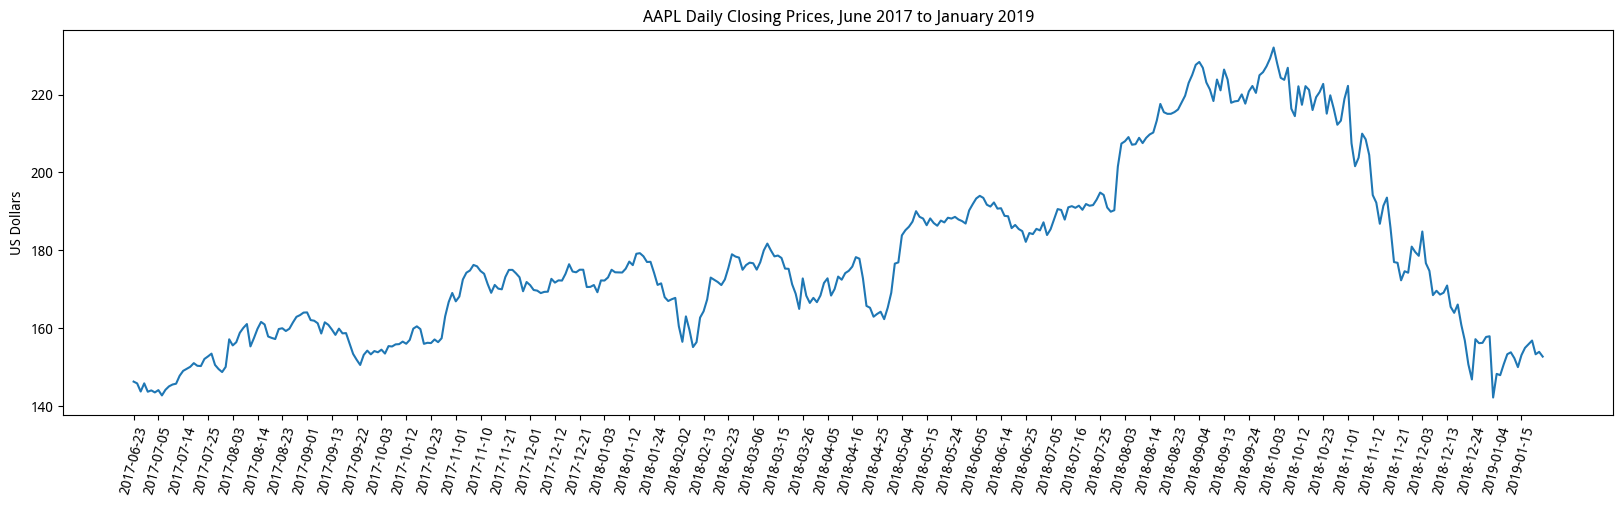

In [26]:
# 400 most recent days
start = -400
end = -1
x = np.arange(len(stock_prices[start:end]))

# Plot roughly one data point per week (x[::7]) so we can display dates 
# without matplotlib going crazy about the labels overlapping
plt.figure(figsize=(20, 5))
plt.xticks(x[::7], stock_dates[start:end:7], fontsize=10, rotation=75)
plt.plot(x, stock_prices[start:end])
plt.title("AAPL Daily Closing Prices, June 2017 to January 2019")
plt.ylabel("US Dollars")
plt.show()

### 你的任务

你的任务是补全下面单元格中的缺失部分，使用长度为 5、25 和 75 的移动平均滤波器来滤除噪声，并回答单元格下方关于结果解释的问题。与 Q2a 不同，这里大部分工作已经为你完成。

在下面的单元格中：
- 分别定义移动平均冲激响应 `MA5, MA25, MA75`。
    - 同样，不需要做任何补零，只在它们的非零点处定义即可。
- 使用 **`"same"` 模式的卷积** 分别用它们滤波测试数据（`data`）。输出分别记为 `y5, y25` 和 `y75`。

*注意：* **这里我们没有像 Q2a 那样使用因果移动平均。** 这样做的动机是：我们希望滤波后的信号能在时间上与原始信号对齐，从而更容易解释结果。实时滤波器必须是因果的，但这里我们处理的是已经收集好的离线数据，因此因果性不那么重要，可解释性更有用。这些性质体现了数据处理方式中的一些权衡。

绘图代码已经提供。加入你自己的代码后，直接运行该单元格即可生成结果。

In [27]:
data = stock_prices[start:end]

In [28]:
## TODO your impulse response definitions here
MA5 = np.full((5, ), 1/5)
MA25 = np.full((25,), 1/25)
MA75 = np.full((75,), 1/75)

In [29]:
## TODO your filtering code here
y5 = np.convolve(data, MA5, mode="same")
y25 = np.convolve(data, MA25, mode="same")
y75 = np.convolve(data, MA75, mode="same")

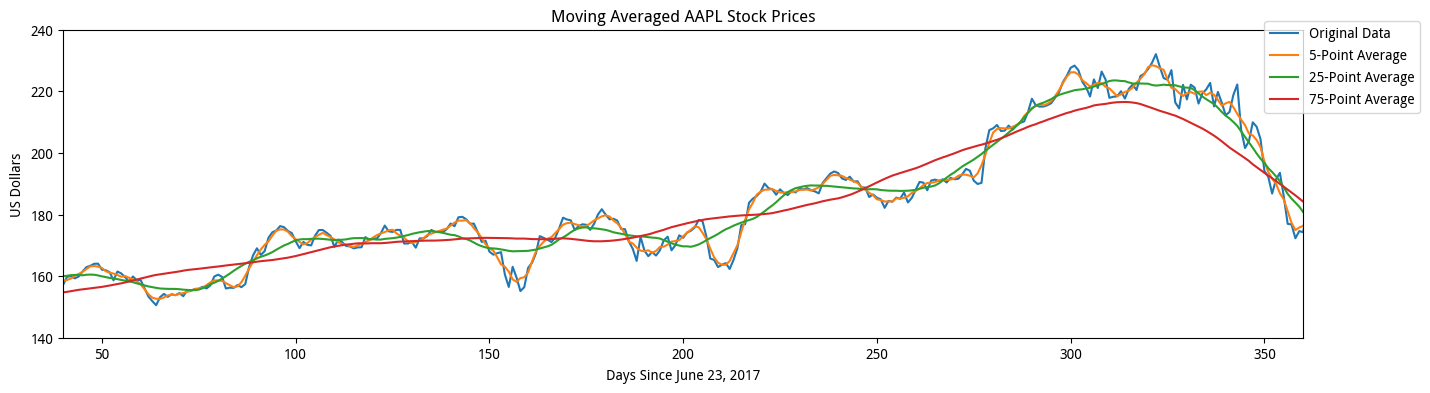

In [30]:
# Overlay stock prices
plt.figure(figsize=(16, 4))
plt.plot(np.arange(len(data)), data)
plt.plot(np.arange(len(data)), y5)
plt.plot(np.arange(len(data)), y25)
plt.plot(np.arange(len(data)), y75)

# Formatting mumbo jumbo to abstract away boundary issues
plt.xlim([40, 360])
plt.ylim([140, 240])
plt.legend(('Original Data', '5-Point Average', '25-Point Average', '75-Point Average'), bbox_to_anchor=(1.1, 1.05))
plt.ylabel("US Dollars")
plt.xlabel("Days Since June 23, 2017")
plt.title("Moving Averaged AAPL Stock Prices")
plt.show()

**问题：** 当我们使用越来越长的移动平均滤波器处理信号（股票数据）时，滤波后的信号突出的是更长期的趋势，还是更短期的趋势？请用 1 到 2 句话解释。

<span style="color:blue">**答案：** 更长期的趋势。</span>

**问题：** 假设你拥有微软股票（MSFT）从上市以来每天的收盘价数据，从 1986 年到现在，大约有 8000 到 10000 个数据点，每天一个。如果你想用移动平均滤波器观察微软股价在“一年左右”时间尺度上的趋势变化，你会使用多长的移动平均窗口？为什么？

<span style="color:blue">**答案：** 我会使用大约 250 天的移动平均，因为一年大约有 252 个交易日。这样可以平滑掉短期波动，同时保留大约一年时间尺度上的趋势变化。</span>

# Q3：MACD 指标

移动平均收敛发散指标（Moving Average Convergence Divergence，MACD）是一种趋势跟随型动量指标，用来展示股票价格的两个移动平均之间的关系。在本题中，我们会借助 MACD 指标来介绍指数移动平均，并进一步展示信号处理在金融分析中的应用。

## 指数移动平均

为了计算一只股票的 MACD，我们首先需要理解一种新的移动平均，称为*指数移动平均*（EMA）。前面我们使用的是简单移动平均（SMA），其中所有点权重相同。EMA 则会给最近的数据点更大的权重，因此最近数据更重要。相比 SMA，EMA 的优势是它能更快地响应最近的价格变化。

### 推导

我们来看 EMA 从哪里来。EMA 可以用下面这个递归的 LCCDE 表示：

$$y[n]=\alpha\cdot x[n] + (1-\alpha)\cdot y[n-1]$$

其中 $y[n]$ 是第 $n$ 天的 EMA，$x[n]$ 是第 $n$ 天的股票价格。那么为什么它叫“指数”移动平均呢？从这个递归式本身看并不一定明显。下面我们一步步展开递归。假设对于所有 $n<0$，$y[n]$ 都为 0，则有：

$\begin{aligned}
    y[0] &= \alpha\cdot x[0] + (1-\alpha)\cdot y[-1] = \alpha\cdot x[0] \\
    y[1] &= \alpha\cdot x[1] + (1-\alpha)\cdot y[0] = \alpha\cdot x[1] + (1-\alpha)\cdot \alpha\cdot x[0] \\
    y[2] &= \alpha\cdot x[2] + (1-\alpha)\cdot y[1] = \alpha\cdot x[2] + (1-\alpha)\cdot (\alpha\cdot x[1] + (1-\alpha)\cdot \alpha\cdot x[0]) = \alpha\cdot x[2] + (1-\alpha)\cdot \alpha\cdot x[1] + (1-\alpha)^2\cdot \alpha\cdot x[0] \\
    &\vdots \\
    y[n] &= \alpha\sum_{k=0}^{n}(1-\alpha)^k\cdot x[n-k]
\end{aligned}$

这样展开后就很清楚了：之所以称为 EMA，是因为越久远的数据点对应的权重会按指数形式不断衰减。

### LTI 视角：EMA 滤波器的冲激响应

我们可以令 $x[n] = \delta[n]$，也就是向 EMA 系统输入 Kronecker delta，从而求出它的冲激响应：

$$h[n]=\alpha\sum_{k=0}^{n}(1-\alpha)^k\cdot \delta[n-k]= \alpha (1-\alpha)^n u[n]$$

这正是我们预期的结果：一个单边衰减指数信号。

## 你的任务

补全下面的 `ema_filter` 函数，使它创建并返回一个在 `length` 个点后截断的 EMA 滤波器冲激响应。$\alpha$ 的值已经为你确定好了。**确保将冲激响应归一化，使其总和为 1。**

In [31]:
def ema_filter(length):
    alpha = 2/(length+1)
    # TODO: Create and return an EMA filter with length "length"
    ema = alpha * np.array([(1 - alpha)**i for i in range(length)])
    ema /= np.sum(ema)
    return ema

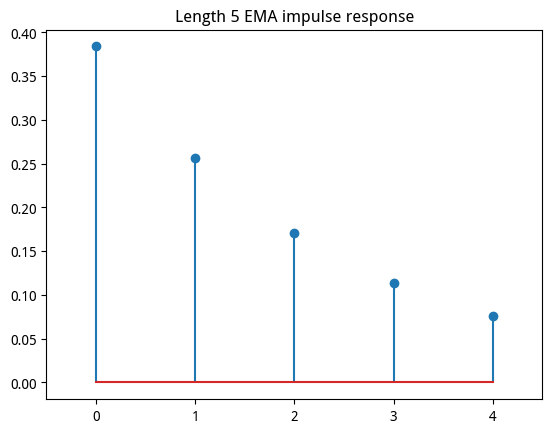

In [32]:
# Run me to plot!
h = ema_filter(5)
plt.figure()
plt.title("Length 5 EMA impulse response")
plt.xlim([-.5, 4.5])
plt.stem(h)
plt.show()

现在我们可以把数据与这个冲激响应卷积，从而计算 EMA。注意，如果我们把这个信号翻转（卷积时会这样做）并让它在某个数据信号上滑动，那么在逐点相乘并求和计算 EMA 时，权重最强的点总是在最前面，随后沿着冲激响应向更久远的位置按指数衰减。

**两个小提示：**

1. 我们最初给出的 LCCDE 描述的是一个 IIR 滤波器，但这里使用的是 FIR 滤波器。毕竟，计算机无法存储无限多个值。为了解决这个问题，我们像通常做法一样截断冲激响应，并且重新归一化，使冲激响应系数之和（称为直流增益 DC gain）为 1。

2. 这里选择的 $\alpha$ 值是出于降低输出噪声方差的考虑。如果你想进一步了解，可以参考下面提供的资料。

## MACD 线

*MACD 线*是通过计算股票 26 日 EMA 和 12 日 EMA 之间的差值得到的。下面单元格中已经基于本实验前面使用的同一组 AAPL 股票数据，为你定义了数组 `data`。请在下面的单元格中计算 MACD 线。具体步骤如下：
- 创建长度为 26 的 EMA 滤波器 $h_{26}$。
- 创建长度为 12 的 EMA 滤波器 $h_{12}$。
- 将 26 日 EMA 计算为 $y_{26} = x * h_{26}$，其中 $x$ 是 `data`。**卷积模式使用 `"valid"`**，因为我们只希望保留两个信号完全重叠的位置。
- 将 12 日 EMA 计算为 $y_{12} = x * h_{12}$。同样使用 `"valid"` 作为卷积模式。
- 通过丢弃 $y_{12}$ 的前 14 个值来裁剪 $y_{12}$，使 $y_{26}$ 和 $y_{12}$ 长度相同。
    - $y_{26}$ 的第一个值是基于第 1 到第 26 个数据点计算的 EMA（因为信号第一次完全重叠是在第 26 天），表示第 26 天的指数平均，并考虑了前 25 天。通过裁掉 $y_{12}$ 的前 14 个值，可以确保它输出的第一个点也对应第 26 天的 EMA，只不过它基于最近 12 天而不是 26 天计算，本质上就是把两个输出“对齐”。
- 计算 MACD 线为 $y_{12} - y_{26}$。**请将结果存储到变量 `MACD` 中，因为后面的绘图代码会使用它。**

完成后，运行下一个单元格绘制结果；下面是工作人员解答中的图，便于你在继续前检查答案是否正确：

<img src="macd.png" width="1100px" />

In [33]:
# Stock data
data = stock_prices[start:end]

# TODO calculate macd line
h26 = ema_filter(26)
h12 = ema_filter(12)
y26 = np.convolve(h26, data, mode="valid")
y12 = np.convolve(h12, data, mode="valid")[14:]
MACD = y12 - y26

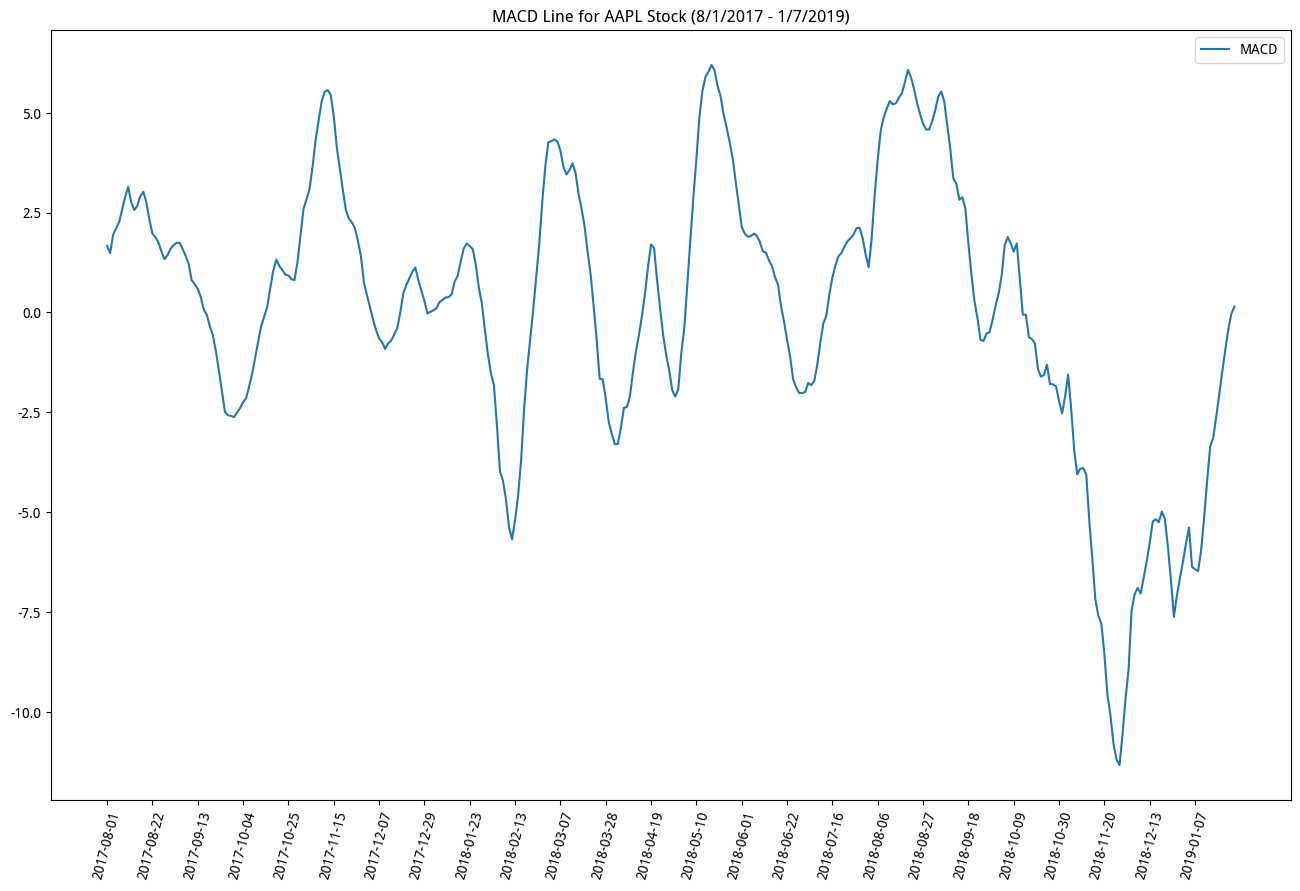

In [35]:
# Plotting Code
x = np.arange(len(MACD))

fig = plt.figure(figsize=(16, 10))

plt.xticks(x[::15], stock_dates[start+26:end:15], fontsize=10, rotation=75)

plt.plot(MACD, label="MACD")

plt.title("MACD Line for AAPL Stock (8/1/2017 - 1/7/2019)")
plt.legend()
plt.show()

## 信号线

现在已经得到了 MACD 线，我们希望对 MACD 线再取 9 日 EMA，从而创建*信号线*。有了 MACD 线和信号线之后，就可以分析股票数据。

请在下面单元格顶部添加代码，通过对上面的 `MACD` 线应用 9 日 EMA 滤波器来计算信号线（这次卷积模式使用 `"same"`）。绘图代码已经提供。**请将结果存储在变量 `signal` 中，因为绘图代码会使用它。**

In [36]:
# TODO your signal line calculation here
h9 = ema_filter(9)
signal = np.convolve(h9, MACD, mode="same")

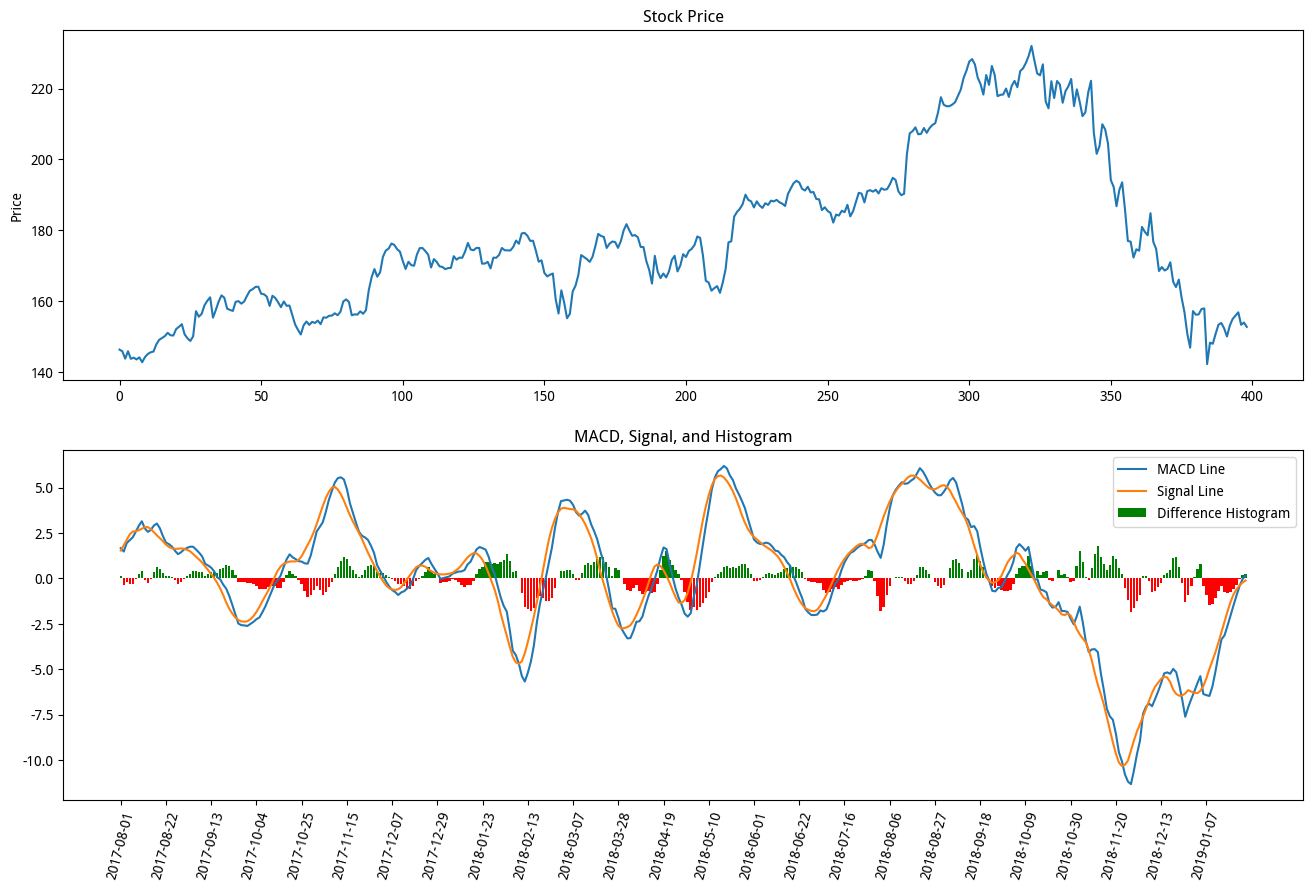

In [37]:
# Plotting Code
c = ['green', 'red']
colors = [c[bool(i)] for i in np.greater(signal, MACD)]
x = np.arange(len(signal))

plt.figure(figsize=(16,10))

plt.subplot(2,1,1)
plt.title("Stock Price")
plt.plot(data)
plt.ylabel("Price")

plt.subplot(2,1,2)
plt.title("MACD, Signal, and Histogram")
plt.xticks(x[::15], stock_dates[start+26:end:15], fontsize=10, rotation=75)
plt.plot(MACD, label='MACD Line')
plt.plot(signal, label='Signal Line')
plt.bar(range(len(signal)),(MACD-signal), color=colors, label="Difference Histogram")
plt.legend()
plt.show()

如果完成正确，你应该看到信号线类似于 MACD 线的平滑版本，并且相对于 MACD 线略微向左偏移；当 MACD 线高于信号线时，差值直方图为绿色，当信号线高于 MACD 线时，差值直方图为红色。

## MACD 指标的解释（来自 *Technical Analysis* [3]）

用信号处理的语言来说，MACD 是对“速度”的一种滤波度量。这个速度经过了两个一阶线性低通滤波器（EMA 滤波器）。信号线则是对这个得到的速度再次滤波。二者之间的差值，也就是直方图，可以看成在三个滤波器共同作用下得到的“加速度”度量。MACD 线与信号线发生交叉，说明加速度方向正在变化。MACD 线穿过零轴，则说明平均速度正在改变方向。

**问题：** 根据速度和加速度的类比，我们可以把股票价格看成汽车的位置。MACD 和直方图分别给出了它的速度和加速度。当差值直方图为正时，这说明股票正在如何变化？我们如何利用这个信息来决定是否投资一只股票？当差值直方图为负时又意味着什么？

<span style="color:blue">**答案：** 当差值直方图为正时，MACD 线位于信号线上方，说明股票的上行动量正在增强，或者下行动量正在减弱。这通常可以理解为看涨信号，因此可能意味着适合买入或继续持有该股票。当差值直方图为负时，MACD 线位于信号线下方，说明股票动量正在减弱或转向下行。这通常可以理解为看跌信号，因此可能意味着应避免买入或考虑卖出。</span>

# 参考文献
[1] 在线信号处理教材中关于移动平均滤波器用于降噪的节选。[链接](https://www.analog.com/media/en/technical-documentation/dsp-book/dsp_book_Ch15.pdf)  
[2] MACD 指标概述。[链接](https://www.investopedia.com/terms/m/macd.asp)  
[3] *Technical Analysis*。[链接](http://www.mrao.cam.ac.uk/~mph/Technical_Analysis.pdf)  
[4] 指数移动平均资料。[链接](https://tttapa.github.io/Pages/Mathematics/Systems-and-Control-Theory/Digital-filters/Exponential%20Moving%20Average/Exponential-Moving-Average.html)